# VAE Pretraining

Post-Train VAE From Saved ChemBL+Zinc Checkpoint
This notebook shows how to resume from the saved pretrained VAE and post-train on tox21.

What this notebook does
- Loads paper_like_selfies_chembl_zinc.pt from artifacts/pretraining_checkpoints/.
- Rebuilds the same VAE architecture and tokenizer mapping used during pretraining.
- Loads tox21 train/val/test data, converts to SELFIES, and encodes with pretrained vocab.
- Runs optional post-training (fine-tuning) and saves a new post-trained checkpoint.

Important
- You do not need to retrain from scratch.
- Post-training starts from pretrained weights loaded from checkpoint.
- Unknown tox21 tokens are mapped to <UNK> so encoding stays compatible.


### Imports and config

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf

try:
    import wandb
except ImportError:
    wandb = None

SEED = 42
MAX_LEN = 120  # max SELFIES token length before EOS
VAL_FRAC = 0.10
TEST_FRAC = 0.10

LATENT_DIM = 292
EPOCHS = 20
BATCH_SIZE = 128
LR = 1e-3
KL_ANNEAL_EPOCHS = 10
FREE_BITS_NATS = 0.1

USE_WANDB = False 
WANDB_PROJECT = "ai-for-toxicology"
WANDB_RUN_NAME = "pretrain-chembl-zinc-seqconv"

CHECKPOINT_DIR = Path("artifacts") / "pretraining_checkpoints"
CHECKPOINT_STEM = "paper_like_selfies_chembl_zinc_seqconv_ce"
SAVE_EPOCH_CHECKPOINTS = True  # Set False if disk usage becomes too high.

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("cuda devices:", torch.cuda.device_count())
print("current device:", torch.cuda.current_device() if torch.cuda.is_available() else None)
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))


device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device:", device)
print("torch:", torch.__version__)
print("selfies:", sf.__version__)
print("wandb:", "available" if wandb is not None else "not installed (optional)")

torch: 2.5.1+cu121
cuda available: True
cuda devices: 1
current device: 0
device name: NVIDIA GeForce RTX 2070
device: cuda
torch: 2.5.1+cu121
selfies: 2.1.1
wandb: available


### Load ChemBL and Zinc datasets

In [2]:
DATA_ROOT = Path("data")
CHEMBL_PATH = DATA_ROOT / "Train" / "chembl_clean.csv"
ZINC_PATH = DATA_ROOT / "Train" / "zinc250k_clean.csv"

for p in [CHEMBL_PATH, ZINC_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Missing file: {p}")


def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    if "canonical_smiles" not in df.columns:
        raise ValueError(f"{path} does not contain canonical_smiles")
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))


chembl_smiles = load_smiles(CHEMBL_PATH)
zinc_smiles = load_smiles(ZINC_PATH)
pretrain_smiles = list(dict.fromkeys(chembl_smiles + zinc_smiles))

print(f"ChemBL unique SMILES: {len(chembl_smiles):,}")
print(f"Zinc unique SMILES:   {len(zinc_smiles):,}")
print(f"Combined unique SMILES for pretraining: {len(pretrain_smiles):,}")


ChemBL unique SMILES: 23,871
Zinc unique SMILES:   249,455
Combined unique SMILES for pretraining: 273,321


### Convert to SELFIES and create the combined pretraining split

In [3]:
def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed


def filter_selfies_len(selfies_list: list[str], max_len: int = MAX_LEN) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


def split_list(items: list[str], val_frac: float, test_frac: float, seed: int) -> tuple[list[str], list[str], list[str]]:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(items))
    rng.shuffle(idx)

    n = len(items)
    n_test = max(1, int(round(n * test_frac)))
    n_val = max(1, int(round(n * val_frac)))

    if n_test + n_val >= n:
        n_test = max(1, n // 10)
        n_val = max(1, n // 10)

    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]

    train = [items[i] for i in train_idx]
    val = [items[i] for i in val_idx]
    test = [items[i] for i in test_idx]
    return train, val, test


pretrain_selfies, pretrain_failed = smiles_to_selfies(pretrain_smiles)
pretrain_selfies = filter_selfies_len(pretrain_selfies, max_len=MAX_LEN)
train_selfies, val_selfies, test_selfies = split_list(pretrain_selfies, VAL_FRAC, TEST_FRAC, seed=SEED)

print(f"SELFIES conversion failures: {pretrain_failed}")
print(
    f"filtered combined split sizes: train={len(train_selfies):,}, "
    f"val={len(val_selfies):,}, test={len(test_selfies):,}"
)


SELFIES conversion failures: 0
filtered combined split sizes: train=218,336, val=27,292, test=27,292


### Tokenization and encoding

In [4]:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"


def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


train_tokens = [tokenize_selfies(s) for s in train_selfies]
vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})
ALL_TOKENS = [PAD, UNK, EOS] + vocab_tokens
TOKEN_TO_IDX = {tok: i for i, tok in enumerate(ALL_TOKENS)}
IDX_TO_TOKEN = {i: tok for tok, i in TOKEN_TO_IDX.items()}

PAD_IDX = TOKEN_TO_IDX[PAD]
UNK_IDX = TOKEN_TO_IDX[UNK]
EOS_IDX = TOKEN_TO_IDX[EOS]

SEQ_LEN = MAX_LEN + 1
VOCAB_SIZE = len(ALL_TOKENS)

if SEQ_LEN < 29:
    raise ValueError("Sequence length is too small for conv kernels (9, 9, 11).")


def encode_selfies(s: str) -> list[int]:
    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out


train_x = encode_list(train_selfies)
val_x = encode_list(val_selfies)
test_x = encode_list(test_selfies)

print(f"train={train_x.shape}, val={val_x.shape}, test={test_x.shape}")
print(f"VOCAB_SIZE={VOCAB_SIZE}, SEQ_LEN={SEQ_LEN}")


train=(218336, 121), val=(27292, 121), test=(27292, 121)
VOCAB_SIZE=115, SEQ_LEN=121


### SELFIES VAE

In [16]:
class TokenDataset(Dataset):
    def __init__(self, x: np.ndarray):
        self.x = torch.from_numpy(x).long()

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx]


class PaperLikeSelfiesVAE(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # Conv1d expects [batch, channels, length], so we encode one-hot SELFIES as [B, vocab, seq].
        self.conv_1 = nn.Conv1d(in_channels=vocab_size, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(501, vocab_size)

    def encoder(self, x_onehot: torch.Tensor):
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z: torch.Tensor):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        logits = self.linear_4(out)
        return logits

    def forward(self, x_onehot: torch.Tensor):
        mean, logvar = self.encoder(x_onehot)
        z = self.sampling(mean, logvar)
        logits = self.decode(z)
        return logits, mean, logvar


def ids_to_onehot(x_ids: torch.Tensor, vocab_size: int):
    return F.one_hot(x_ids, num_classes=vocab_size).float().transpose(1, 2).contiguous()


def vae_loss(
    logits: torch.Tensor,
    x_ids: torch.Tensor,
    mean: torch.Tensor,
    logvar: torch.Tensor,
    *,
    pad_idx: int,
    beta: float = 1.0,
    free_bits_nats: float = 0.0,
):
    vocab_size = logits.size(-1)
    recon_sum = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        x_ids.reshape(-1),
        ignore_index=pad_idx,
        reduction="sum",
    )

    kl_per_dim = -0.5 * (1 + logvar - mean.pow(2) - logvar.exp())
    if free_bits_nats and free_bits_nats > 0:
        kl_per_dim = torch.clamp(kl_per_dim, min=float(free_bits_nats))
    kl_sum = kl_per_dim.sum()

    n_nonpad = (x_ids != pad_idx).sum().clamp(min=1)
    total = recon_sum + beta * kl_sum
    return total, recon_sum, kl_sum, n_nonpad


def kl_beta(epoch: int, anneal_epochs: int) -> float:
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))


### Training and evaluation helpers

In [ ]:
def make_loader(x: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(TokenDataset(x), batch_size=batch_size, shuffle=shuffle)


def init_wandb(*, run_name: str | None = None, epochs: int | None = None):
    if not USE_WANDB:
        return None
    if wandb is None:
        raise ImportError("wandb is not installed. Install it or set USE_WANDB=False.")

    return wandb.init(
        project=WANDB_PROJECT,
        name=run_name or WANDB_RUN_NAME,
        config={
            "seed": SEED,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "epochs": epochs if epochs is not None else EPOCHS,
            "batch_size": BATCH_SIZE,
            "lr": LR,
            "kl_anneal_epochs": KL_ANNEAL_EPOCHS,
            "free_bits_nats": FREE_BITS_NATS,
            "vocab_size": VOCAB_SIZE,
            "seq_len": SEQ_LEN,
        },
    )


def run_epoch(model: nn.Module, loader: DataLoader, *, optimizer=None, beta: float = 1.0):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_sum = 0.0
    recon_sum = 0.0
    kl_sum = 0.0
    n_samples = 0
    n_nonpad = 0
    n_correct = 0

    for x_ids in loader:
        x_ids = x_ids.to(device)
        x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits, mean, logvar = model(x_onehot)
            total, recon, kl, nonpad = vae_loss(
                logits,
                x_ids,
                mean,
                logvar,
                pad_idx=PAD_IDX,
                beta=beta,
                free_bits_nats=FREE_BITS_NATS,
            )
            if is_train:
                total.backward()
                optimizer.step()

        mask = x_ids != PAD_IDX
        preds = logits.argmax(dim=-1)

        total_sum += total.item()
        recon_sum += recon.item()
        kl_sum += kl.item()
        n_samples += x_ids.size(0)
        n_nonpad += int(nonpad.item())
        n_correct += ((preds == x_ids) & mask).sum().item()

    return {
        "total": total_sum / max(n_samples, 1),
        "recon_per_token": recon_sum / max(n_nonpad, 1),
        "kl": kl_sum / max(n_samples, 1),
        "token_acc": n_correct / max(n_nonpad, 1),
    }


def evaluate(model: nn.Module, x: np.ndarray, *, beta: float):
    loader = make_loader(x, batch_size=BATCH_SIZE, shuffle=False)
    return run_epoch(model, loader, optimizer=None, beta=beta)


def _checkpoint_payload(
    model: nn.Module,
    history: dict,
    *,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    test_metrics: dict | None = None,
):
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "epoch": int(epoch),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_total": float(best_val_total) if best_val_total is not None else None,
        "token_to_idx": TOKEN_TO_IDX,
        "seq_len": SEQ_LEN,
        "vocab_size": VOCAB_SIZE,
        "max_len": MAX_LEN,
        "pad_idx": PAD_IDX,
        "unk_idx": UNK_IDX,
        "eos_idx": EOS_IDX,
        "history": history,
        "test_metrics": test_metrics,
        "encoder_layout": "onehot_channels_first_seqconv",
        "decoder_output": "logits",
        "loss_name": "token_cross_entropy_plus_kl",
    }


def _save_training_checkpoints(
    model: nn.Module,
    history: dict,
    *,
    save_dir: Path,
    checkpoint_stem: str,
    epoch: int,
    best_epoch: int | None,
    best_val_total: float | None,
    optimizer=None,
    is_best: bool,
    save_epoch_checkpoints: bool,
):
    payload = _checkpoint_payload(
        model,
        history,
        epoch=epoch,
        best_epoch=best_epoch,
        best_val_total=best_val_total,
        optimizer=optimizer,
        test_metrics=None,
    )

    last_path = save_dir / f"{checkpoint_stem}_last.pt"
    torch.save(payload, last_path)

    if save_epoch_checkpoints:
        epoch_path = save_dir / f"{checkpoint_stem}_epoch_{epoch:03d}.pt"
        torch.save(payload, epoch_path)

    if is_best:
        best_path = save_dir / f"{checkpoint_stem}_best.pt"
        torch.save(payload, best_path)


def train_model(
    train_x: np.ndarray,
    val_x: np.ndarray,
    *,
    model: nn.Module | None = None,
    optimizer=None,
    history: dict | None = None,
    start_epoch: int = 0,
    num_epochs: int = EPOCHS,
    checkpoint_dir: Path | None = None,
    checkpoint_stem: str | None = None,
    save_epoch_checkpoints: bool = SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name: str | None = None,
):
    if model is None:
        model = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
    if optimizer is None:
        optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_loader = make_loader(train_x, batch_size=BATCH_SIZE, shuffle=True)

    if history is None:
        history = {
            "beta": [],
            "train_total": [],
            "val_total": [],
            "train_recon_per_token": [],
            "val_recon_per_token": [],
            "train_kl": [],
            "val_kl": [],
            "train_token_acc": [],
            "val_token_acc": [],
        }
    else:
        for key in [
            "beta",
            "train_total",
            "val_total",
            "train_recon_per_token",
            "val_recon_per_token",
            "train_kl",
            "val_kl",
            "train_token_acc",
            "val_token_acc",
        ]:
            history.setdefault(key, [])

    if history["val_total"]:
        best_idx = int(np.argmin(history["val_total"]))
        best_epoch = best_idx + 1
        best_val_total = float(history["val_total"][best_idx])
    else:
        best_epoch = None
        best_val_total = float("inf")

    if checkpoint_dir is not None and checkpoint_stem is not None:
        checkpoint_dir = Path(checkpoint_dir)
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

    wandb_run = init_wandb(run_name=wandb_run_name, epochs=num_epochs)

    for rel_ep in range(1, num_epochs + 1):
        ep = start_epoch + rel_ep
        beta = kl_beta(ep, KL_ANNEAL_EPOCHS)
        train_metrics = run_epoch(model, train_loader, optimizer=optimizer, beta=beta)
        val_metrics = evaluate(model, val_x, beta=beta)

        history["beta"].append(beta)
        history["train_total"].append(train_metrics["total"])
        history["val_total"].append(val_metrics["total"])
        history["train_recon_per_token"].append(train_metrics["recon_per_token"])
        history["val_recon_per_token"].append(val_metrics["recon_per_token"])
        history["train_kl"].append(train_metrics["kl"])
        history["val_kl"].append(val_metrics["kl"])
        history["train_token_acc"].append(train_metrics["token_acc"])
        history["val_token_acc"].append(val_metrics["token_acc"])

        is_best = val_metrics["total"] < best_val_total
        if is_best:
            best_val_total = float(val_metrics["total"])
            best_epoch = ep

        print(
            f"epoch {ep:03d} | beta={beta:.2f} | "
            f"train total={train_metrics['total']:.4f} | val total={val_metrics['total']:.4f} | "
            f"train token acc={train_metrics['token_acc']:.4f} | val token acc={val_metrics['token_acc']:.4f}"
            + (" | new best" if is_best else "")
        )

        if checkpoint_dir is not None and checkpoint_stem is not None:
            _save_training_checkpoints(
                model,
                history,
                save_dir=checkpoint_dir,
                checkpoint_stem=checkpoint_stem,
                epoch=ep,
                best_epoch=best_epoch,
                best_val_total=best_val_total,
                optimizer=optimizer,
                is_best=is_best,
                save_epoch_checkpoints=save_epoch_checkpoints,
            )

        if wandb_run is not None:
            wandb_run.log(
                {
                    "epoch": ep,
                    "beta": beta,
                    "train/total": train_metrics["total"],
                    "val/total": val_metrics["total"],
                    "train/recon_per_token": train_metrics["recon_per_token"],
                    "val/recon_per_token": val_metrics["recon_per_token"],
                    "train/kl": train_metrics["kl"],
                    "val/kl": val_metrics["kl"],
                    "train/token_acc": train_metrics["token_acc"],
                    "val/token_acc": val_metrics["token_acc"],
                    "best/val_total": best_val_total,
                    "best/epoch": best_epoch,
                },
                step=ep,
            )

    if wandb_run is not None:
        wandb_run.finish()

    checkpoint_info = {
        "best_epoch": best_epoch,
        "best_val_total": best_val_total,
        "last_epoch": start_epoch + num_epochs,
    }
    return model, history, checkpoint_info


### Train the ChemBL + Zinc pretraining model

In [30]:
save_dir = CHECKPOINT_DIR
save_dir.mkdir(parents=True, exist_ok=True)

print("Training on the combined ChemBL + Zinc pretraining set...")
model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    checkpoint_dir=save_dir,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

# Keep the legacy single-checkpoint path for backwards compatibility.
ckpt_path = save_dir / f"{CHECKPOINT_STEM}.pt"
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=len(history["beta"]),
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=None,
        test_metrics=test_metrics,
    ),
    ckpt_path,
)

results_df = pd.DataFrame(
    [
        {
            "run_name": "chembl_zinc",
            "n_train": len(train_x),
            "n_val": len(val_x),
            "n_test": len(test_x),
            "final_train_total": history["train_total"][-1],
            "final_val_total": history["val_total"][-1],
            "final_train_token_acc": history["train_token_acc"][-1],
            "final_val_token_acc": history["val_token_acc"][-1],
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_recon_per_token": test_metrics["recon_per_token"],
            "test_kl": test_metrics["kl"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(save_dir / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(save_dir / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_compat": str(ckpt_path),
        }
    ]
)
results_df


Training on the combined ChemBL + Zinc pretraining set...


NameError: name 'PaperLikeSelfiesVAE' is not defined

### Plot training curves

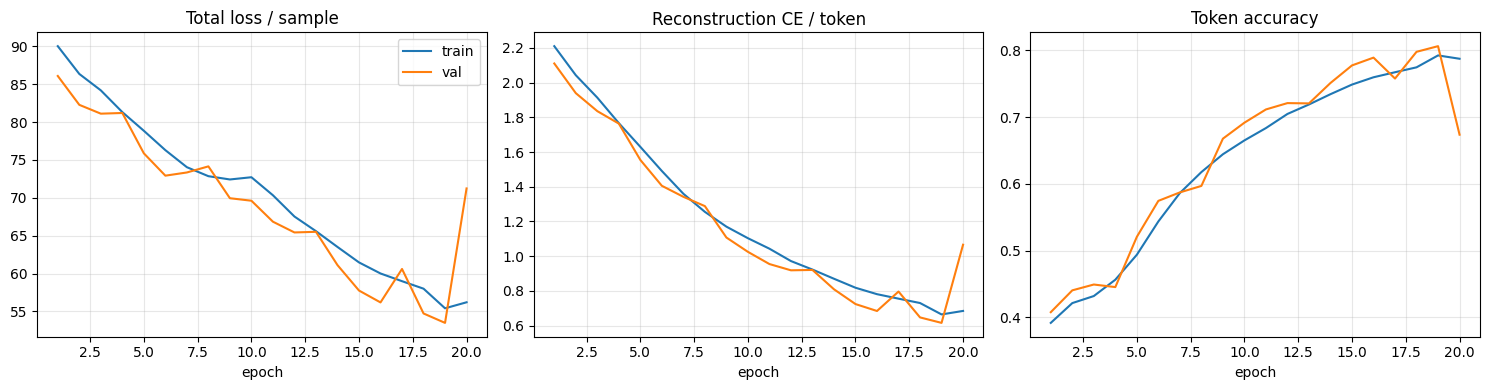

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = np.arange(1, len(history["train_total"]) + 1)

axes[0].plot(epochs, history["train_total"], label="train")
axes[0].plot(epochs, history["val_total"], label="val")
axes[0].set_title("Total loss / sample")
axes[0].set_xlabel("epoch")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, history["train_recon_per_token"], label="train")
axes[1].plot(epochs, history["val_recon_per_token"], label="val")
axes[1].set_title("Reconstruction CE / token")
axes[1].set_xlabel("epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history["train_token_acc"], label="train")
axes[2].plot(epochs, history["val_token_acc"], label="val")
axes[2].set_title("Token accuracy")
axes[2].set_xlabel("epoch")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Quick reconstruction check

In [11]:
def decode_ids_to_selfies(ids: np.ndarray | list[int]) -> str:
    toks = []
    for idx in ids:
        tok = IDX_TO_TOKEN[int(idx)]
        if tok == EOS:
            break
        if tok == PAD:
            continue
        toks.append(tok)
    return "".join(toks)


def show_reconstructions(n: int = 5, seed: int = 42):
    model.eval()

    rng = np.random.default_rng(seed)
    k = min(n, len(test_x))
    idxs = rng.choice(len(test_x), size=k, replace=False)

    x_ids = torch.from_numpy(test_x[idxs]).long().to(device)
    x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)

    with torch.no_grad():
        logits, _, _ = model(x_onehot)
        pred_ids = logits.argmax(dim=-1).cpu().numpy()

    for j, idx in enumerate(idxs):
        orig_selfies = test_selfies[idx]
        pred_selfies = decode_ids_to_selfies(pred_ids[j])
        exact = orig_selfies == pred_selfies
        print(f"[{j}] exact={exact}")
        print("orig:", orig_selfies)
        print("pred:", pred_selfies)
        print()


show_reconstructions(n=5, seed=SEED)


[0] exact=False
orig: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C@@H1][Branch1][Ring2][C][Ring1][#Branch1][NH2+1][Ring1][=Branch1]
pred: [C][C][Branch1][C][C][C@H1][Branch1][C][C][C][N][C][=Branch1][C][=O][C][C][C][C@H1][C][C][C][Branch1][C][C][Ring1][Branch1][C][Ring1][Ring1]

[1] exact=False
orig: [C][C][C@@H1][Branch2][Ring1][=Branch1][O][C][=Branch1][C][=O][C][=C][C][=C][C][Branch1][#Branch1][N][C][Branch1][C][C][=O][=C][Ring1][#Branch2][C][=Branch1][C][=O][N][C][C][=C][Branch1][C][C][O][N][=Ring1][=Branch1]
pred: [C][C][C@H1][Branch2][Ring1][#Branch1][C][C][=Branch1][C][=O][C][=C][C][C][=C][Ring1][=Branch1][C][C][Branch1][C][C][C][C][Ring1][Branch1][C][=Branch1][C][=O][N][C][C][=N][C][Branch1][C][C][C][Ring1][Ring1]

[2] exact=False
orig: [Cl][C][C@H1][C][C][C][O][C@H1][Ring1][=Branch1][C][=C][C][=C][Branch1][C][Cl][S][Ring1][=Branch1]
pred: [C][C][C@H1][C][C][C][C][C@H1][Ring1][Branch1][C][=C][C][=C][Branch1][C][Cl][O][Ring1][#Branc

### Notes for later tox21 post-training
This notebook now saves a new sequence-convolution checkpoint. Update the model definition in the post-training notebook before loading it, or keep using the older checkpoint if you want the old architecture.


### Temporary: continue training for +10 epochs from the latest checkpoint


In [14]:
EXTRA_EPOCHS = 10

resume_last_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"
legacy_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}.pt"
resume_path = resume_last_path if resume_last_path.exists() else legacy_path

if not resume_path.exists():
    raise FileNotFoundError(
        f"Could not find a checkpoint to resume from. Checked: {resume_last_path} and {legacy_path}"
    )

print("Resuming from:", resume_path)
resume_bundle = torch.load(resume_path, map_location=device)

model_resume = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_resume.load_state_dict(resume_bundle["model_state_dict"])

optimizer_resume = torch.optim.Adam(model_resume.parameters(), lr=LR)
if resume_bundle.get("optimizer_state_dict") is not None:
    optimizer_resume.load_state_dict(resume_bundle["optimizer_state_dict"])
else:
    print("No optimizer state found in checkpoint; using fresh Adam optimizer.")

history_resume = resume_bundle.get("history")
if history_resume is not None and "beta" in history_resume:
    start_epoch = int(resume_bundle.get("epoch", len(history_resume["beta"])))
else:
    history_resume = None
    start_epoch = int(resume_bundle.get("epoch", 0))

print(f"Loaded start_epoch={start_epoch}. Will train through epoch {start_epoch + EXTRA_EPOCHS}.")


Resuming from: artifacts/pretraining_checkpoints/paper_like_selfies_chembl_zinc_seqconv_ce.pt
No optimizer state found in checkpoint; using fresh Adam optimizer.
Loaded start_epoch=20. Will train through epoch 30.


In [18]:
continued_run_name = f"{WANDB_RUN_NAME}-resume-{start_epoch + EXTRA_EPOCHS}"

model, history, checkpoint_info = train_model(
    train_x,
    val_x,
    model=model_resume,
    optimizer=optimizer_resume,
    history=history_resume,
    start_epoch=start_epoch,
    num_epochs=EXTRA_EPOCHS,
    checkpoint_dir=CHECKPOINT_DIR,
    checkpoint_stem=CHECKPOINT_STEM,
    save_epoch_checkpoints=SAVE_EPOCH_CHECKPOINTS,
    wandb_run_name=continued_run_name,
)

final_beta = history["beta"][-1]
test_metrics = evaluate(model, test_x, beta=final_beta)

final_epoch = len(history["beta"])
continuation_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_continued_to_epoch_{final_epoch:03d}.pt"
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    continuation_ckpt_path,
)

# Refresh *_last with test metrics from the continued model.
torch.save(
    _checkpoint_payload(
        model,
        history,
        epoch=final_epoch,
        best_epoch=checkpoint_info["best_epoch"],
        best_val_total=checkpoint_info["best_val_total"],
        optimizer=optimizer_resume,
        test_metrics=test_metrics,
    ),
    CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt",
)

pd.DataFrame(
    [
        {
            "start_epoch": start_epoch,
            "end_epoch": final_epoch,
            "best_epoch": checkpoint_info["best_epoch"],
            "best_val_total": checkpoint_info["best_val_total"],
            "test_total": test_metrics["total"],
            "test_token_acc": test_metrics["token_acc"],
            "checkpoint_best": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"),
            "checkpoint_last": str(CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_last.pt"),
            "checkpoint_continued": str(continuation_ckpt_path),
        }
    ]
)


epoch 021 | beta=1.00 | train total=56.0645 | val total=77.4692 | train token acc=0.7892 | val token acc=0.6110
epoch 022 | beta=1.00 | train total=53.1101 | val total=50.7707 | train token acc=0.8100 | val token acc=0.8273 | new best
epoch 023 | beta=1.00 | train total=51.2929 | val total=55.4964 | train token acc=0.8231 | val token acc=0.7942
epoch 024 | beta=1.00 | train total=60.8528 | val total=55.0665 | train token acc=0.7556 | val token acc=0.7953
epoch 025 | beta=1.00 | train total=56.4252 | val total=50.6999 | train token acc=0.7876 | val token acc=0.8292 | new best
epoch 026 | beta=1.00 | train total=50.3565 | val total=48.3512 | train token acc=0.8310 | val token acc=0.8460 | new best
epoch 027 | beta=1.00 | train total=56.6366 | val total=48.9069 | train token acc=0.7875 | val token acc=0.8425
epoch 028 | beta=1.00 | train total=57.1128 | val total=48.1932 | train token acc=0.7827 | val token acc=0.8479 | new best
epoch 029 | beta=1.00 | train total=58.0130 | val total=50.0

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/epoch,▁▃▃▃▅▅▅▇▇█
best/val_total,█▆▆▆▆▃▃▃▃▁
beta,▁▁▁▁▁▁▁▁▁▁
epoch,▁▂▃▃▄▅▆▆▇█
train/kl,▇██▆▄▅▃▃▂▁
train/recon_per_token,▅▄▃█▆▂▆▆▆▁
train/token_acc,▄▅▆▁▃▇▃▃▃█
train/total,▅▄▃█▆▂▆▆▆▁
val/kl,█▅▆▂▃▄▄▃▁▂
val/recon_per_token,█▂▃▃▂▂▂▂▂▁
+2,...


,start_epoch,end_epoch,best_epoch,best_val_total,test_total,test_token_acc,checkpoint_best,checkpoint_last,checkpoint_continued
0,20,30,30,45.675472,45.803002,0.867677,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...,artifacts/pretraining_checkpoints/paper_like_s...


# Test on Tox 21 test set!

## XGBoost on tox21 using VAE latent features
Use the best pretrained VAE checkpoint to extract latent means (`mu`) from tox21 SMILES, then train one XGBoost classifier per tox21 task.

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)

TOX21_TRAIN_PATH = Path("data") / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = Path("data") / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"

best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])
model_best.eval()

TASKS = [c for c in pd.read_csv(TOX21_TRAIN_PATH, nrows=1).columns if c.startswith("NR-") or c.startswith("SR-")]


def _smiles_to_ids_for_vocab(smiles: str):
    try:
        s = sf.encoder(smiles)
        toks = list(sf.split_selfies(s))
    except Exception:
        return None

    if len(toks) > MAX_LEN:
        return None

    ids = [TOKEN_TO_IDX.get(tok, UNK_IDX) for tok in toks[:MAX_LEN]]
    ids.append(EOS_IDX)

    arr = np.full(SEQ_LEN, PAD_IDX, dtype=np.int64)
    arr[:len(ids)] = ids
    return arr


def build_latent_split(csv_path: Path, task_cols: list[str], batch_size: int = 512):
    df = pd.read_csv(csv_path).dropna(subset=["canonical_smiles"]).reset_index(drop=True)
    y_all = df[task_cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)

    x_ids_list, y_kept = [], []
    failed = 0
    for smi, y in zip(df["canonical_smiles"].astype(str).tolist(), y_all):
        ids = _smiles_to_ids_for_vocab(smi)
        if ids is None:
            failed += 1
            continue
        x_ids_list.append(ids)
        y_kept.append(y)

    x_ids = np.stack(x_ids_list)
    y = np.stack(y_kept)

    z_chunks = []
    with torch.no_grad():
        for i in range(0, len(x_ids), batch_size):
            xb = torch.from_numpy(x_ids[i:i + batch_size]).long().to(device)
            x_onehot_seq_vocab = F.one_hot(xb, num_classes=VOCAB_SIZE).float()
            x_onehot_vocab_seq = x_onehot_seq_vocab.transpose(1, 2).contiguous()
            mean, _ = model_best.encoder(x_onehot_vocab_seq)
            z_chunks.append(mean.cpu().numpy())

    z = np.vstack(z_chunks)
    return z, y, failed


Z_train, Y_train, fail_train = build_latent_split(TOX21_TRAIN_PATH, TASKS)
Z_val, Y_val, fail_val = build_latent_split(TOX21_VAL_PATH, TASKS)
Z_test, Y_test, fail_test = build_latent_split(TOX21_TEST_PATH, TASKS)

print("Loaded latent feature matrices:")
print(f"train: Z={Z_train.shape}, Y={Y_train.shape}, skipped={fail_train}")
print(f"val  : Z={Z_val.shape}, Y={Y_val.shape}, skipped={fail_val}")
print(f"test : Z={Z_test.shape}, Y={Y_test.shape}, skipped={fail_test}")

Loaded latent feature matrices:
train: Z=(6237, 292), Y=(6237, 12), skipped=21
val  : Z=(770, 292), Y=(770, 12), skipped=12
test : Z=(765, 292), Y=(765, 12), skipped=18


In [22]:
task_rows = []
roc_curves = {}
pr_curves = {}

for j, task in enumerate(TASKS):
    ytr, yv, yt = Y_train[:, j], Y_val[:, j], Y_test[:, j]

    mtr = np.isin(ytr, [0, 1])
    mv = np.isin(yv, [0, 1])
    mt = np.isin(yt, [0, 1])

    # Need both classes for training and evaluation
    if len(np.unique(ytr[mtr])) < 2 or len(np.unique(yt[mt])) < 2:
        continue

    clf = XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1,
    )
    clf.fit(Z_train[mtr], ytr[mtr], eval_set=[(Z_val[mv], yv[mv])], verbose=False)

    p_val = clf.predict_proba(Z_val[mv])[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t = max(
        thresholds,
        key=lambda t: f1_score(yv[mv], (p_val >= t).astype(int), zero_division=0),
    )

    p_test = clf.predict_proba(Z_test[mt])[:, 1]
    y_true = yt[mt].astype(int)
    y_hat = (p_test >= best_t).astype(int)

    auroc = roc_auc_score(y_true, p_test)
    auprc = average_precision_score(y_true, p_test)

    task_rows.append(
        {
            "task": task,
            "n_test": int(mt.sum()),
            "threshold": float(best_t),
            "AUROC": float(auroc),
            "AUPRC": float(auprc),
            "Accuracy": float(accuracy_score(y_true, y_hat)),
            "F1": float(f1_score(y_true, y_hat, zero_division=0)),
            "Precision": float(precision_score(y_true, y_hat, zero_division=0)),
            "Recall": float(recall_score(y_true, y_hat, zero_division=0)),
        }
    )

    fpr, tpr, _ = roc_curve(y_true, p_test)
    prec, rec, _ = precision_recall_curve(y_true, p_test)
    roc_curves[task] = (fpr, tpr, auroc)
    pr_curves[task] = (rec, prec, auprc, float(y_true.mean()))

metrics_df = pd.DataFrame(task_rows).sort_values("AUROC", ascending=False).reset_index(drop=True)
metrics_df

,task,n_test,threshold,AUROC,AUPRC,Accuracy,F1,Precision,Recall
0,NR-AR-LBD,765,0.25,0.756667,0.292186,0.973856,0.333333,0.454545,0.263158
1,SR-ATAD5,765,0.05,0.728001,0.099894,0.942484,0.083333,0.125000,0.062500
2,NR-AhR,765,0.10,0.704291,0.263756,0.798693,0.324561,0.270073,0.406593
3,NR-AR,765,0.40,0.694919,0.237223,0.964706,0.307692,0.428571,0.240000
4,NR-ER-LBD,765,0.20,0.671915,0.123758,0.966013,0.071429,0.142857,0.047619
5,SR-MMP,765,0.10,0.669690,0.206388,0.720261,0.272109,0.200000,0.425532
6,NR-ER,765,0.25,0.624124,0.163291,0.898039,0.113636,0.250000,0.073529
7,SR-p53,765,0.05,0.620735,0.160594,0.877124,0.203390,0.230769,0.181818
8,NR-Aromatase,765,0.05,0.601832,0.092292,0.918954,0.060606,0.100000,0.043478
9,NR-PPAR-gamma,765,0.05,0.566316,0.046606,0.969935,0.000000,0.000000,0.000000


In [23]:
print("Macro average metrics:")
metrics_df[["AUROC", "AUPRC", "Accuracy", "F1", "Precision", "Recall"]].mean().to_frame("macro_mean").T

Macro average metrics:


,AUROC,AUPRC,Accuracy,F1,Precision,Recall
macro_mean,0.643046,0.161176,0.885512,0.174376,0.211988,0.174507


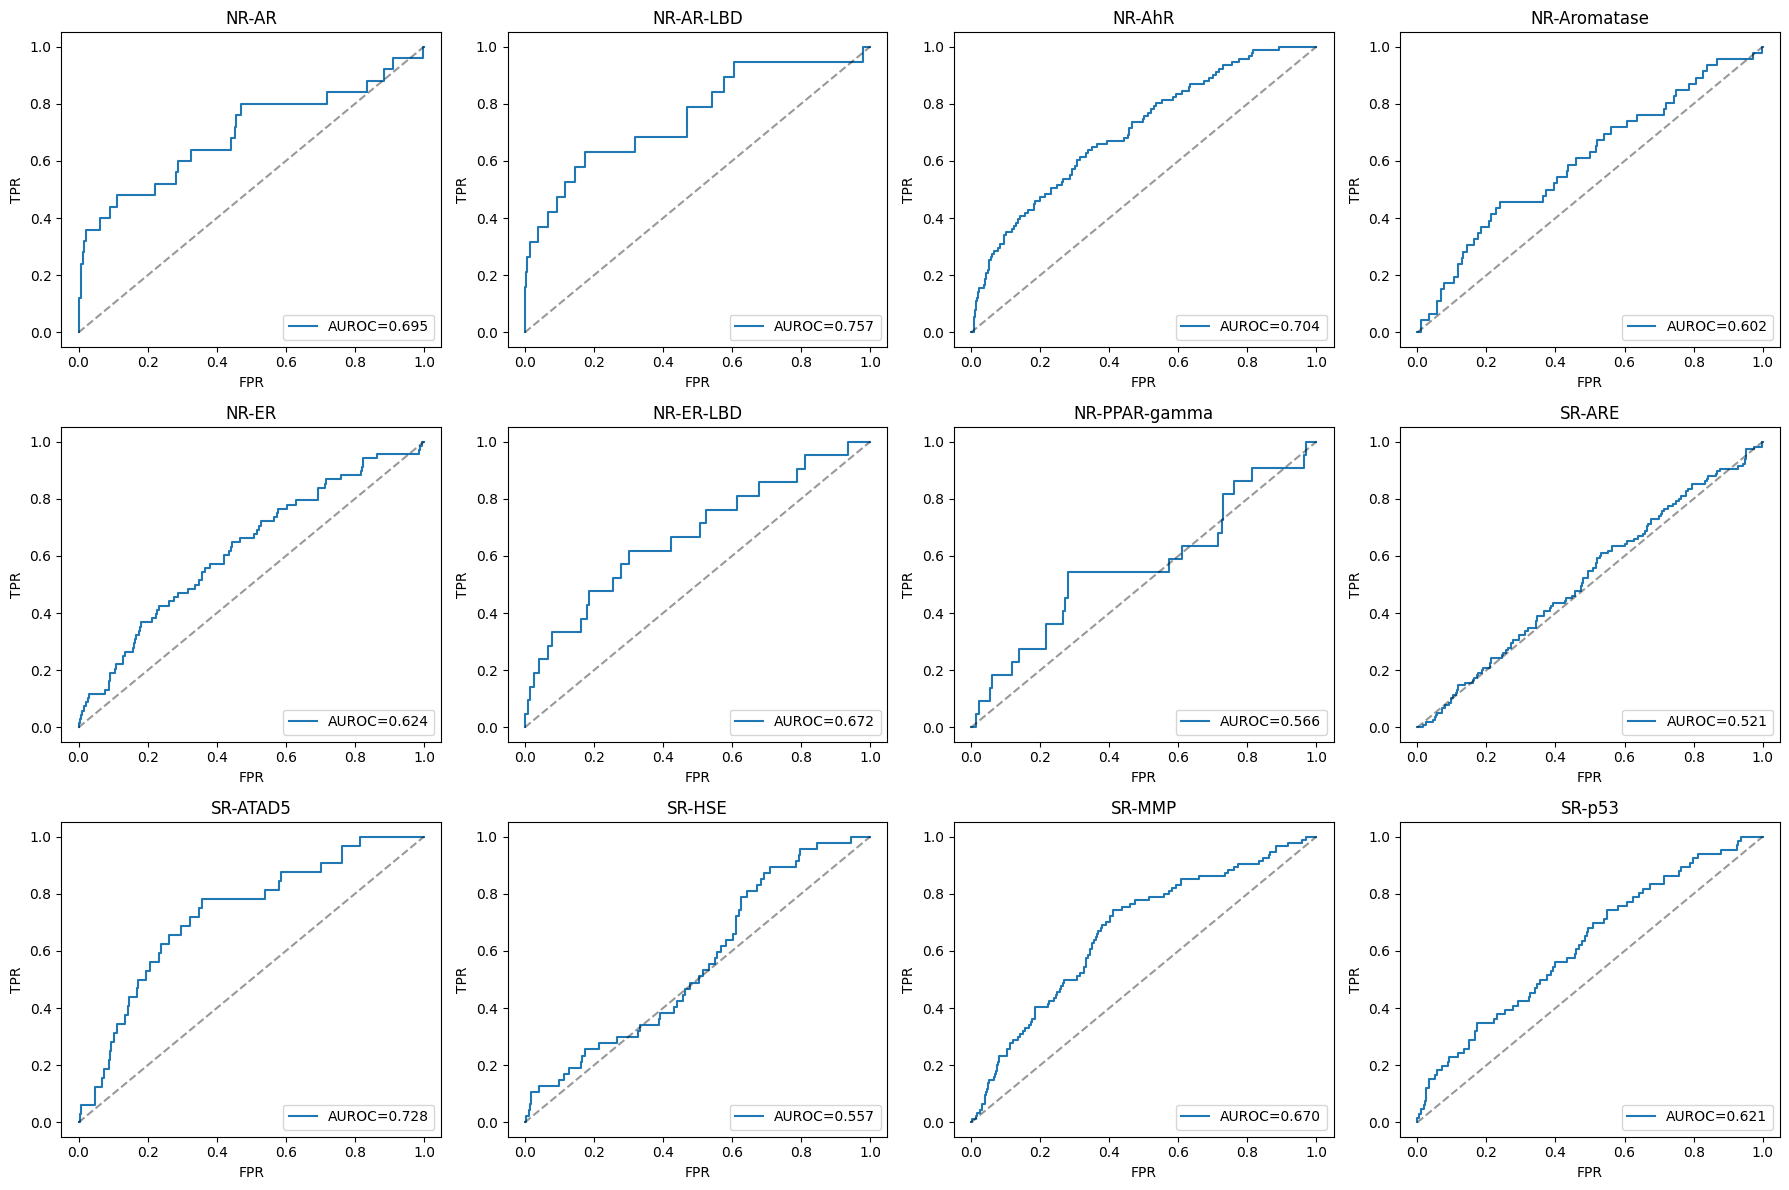

In [24]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in roc_curves:
        fpr, tpr, auc = roc_curves[task]
        ax.plot(fpr, tpr, label=f"AUROC={auc:.3f}")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("FPR")
        ax.set_ylabel("TPR")
        ax.legend(loc="lower right")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

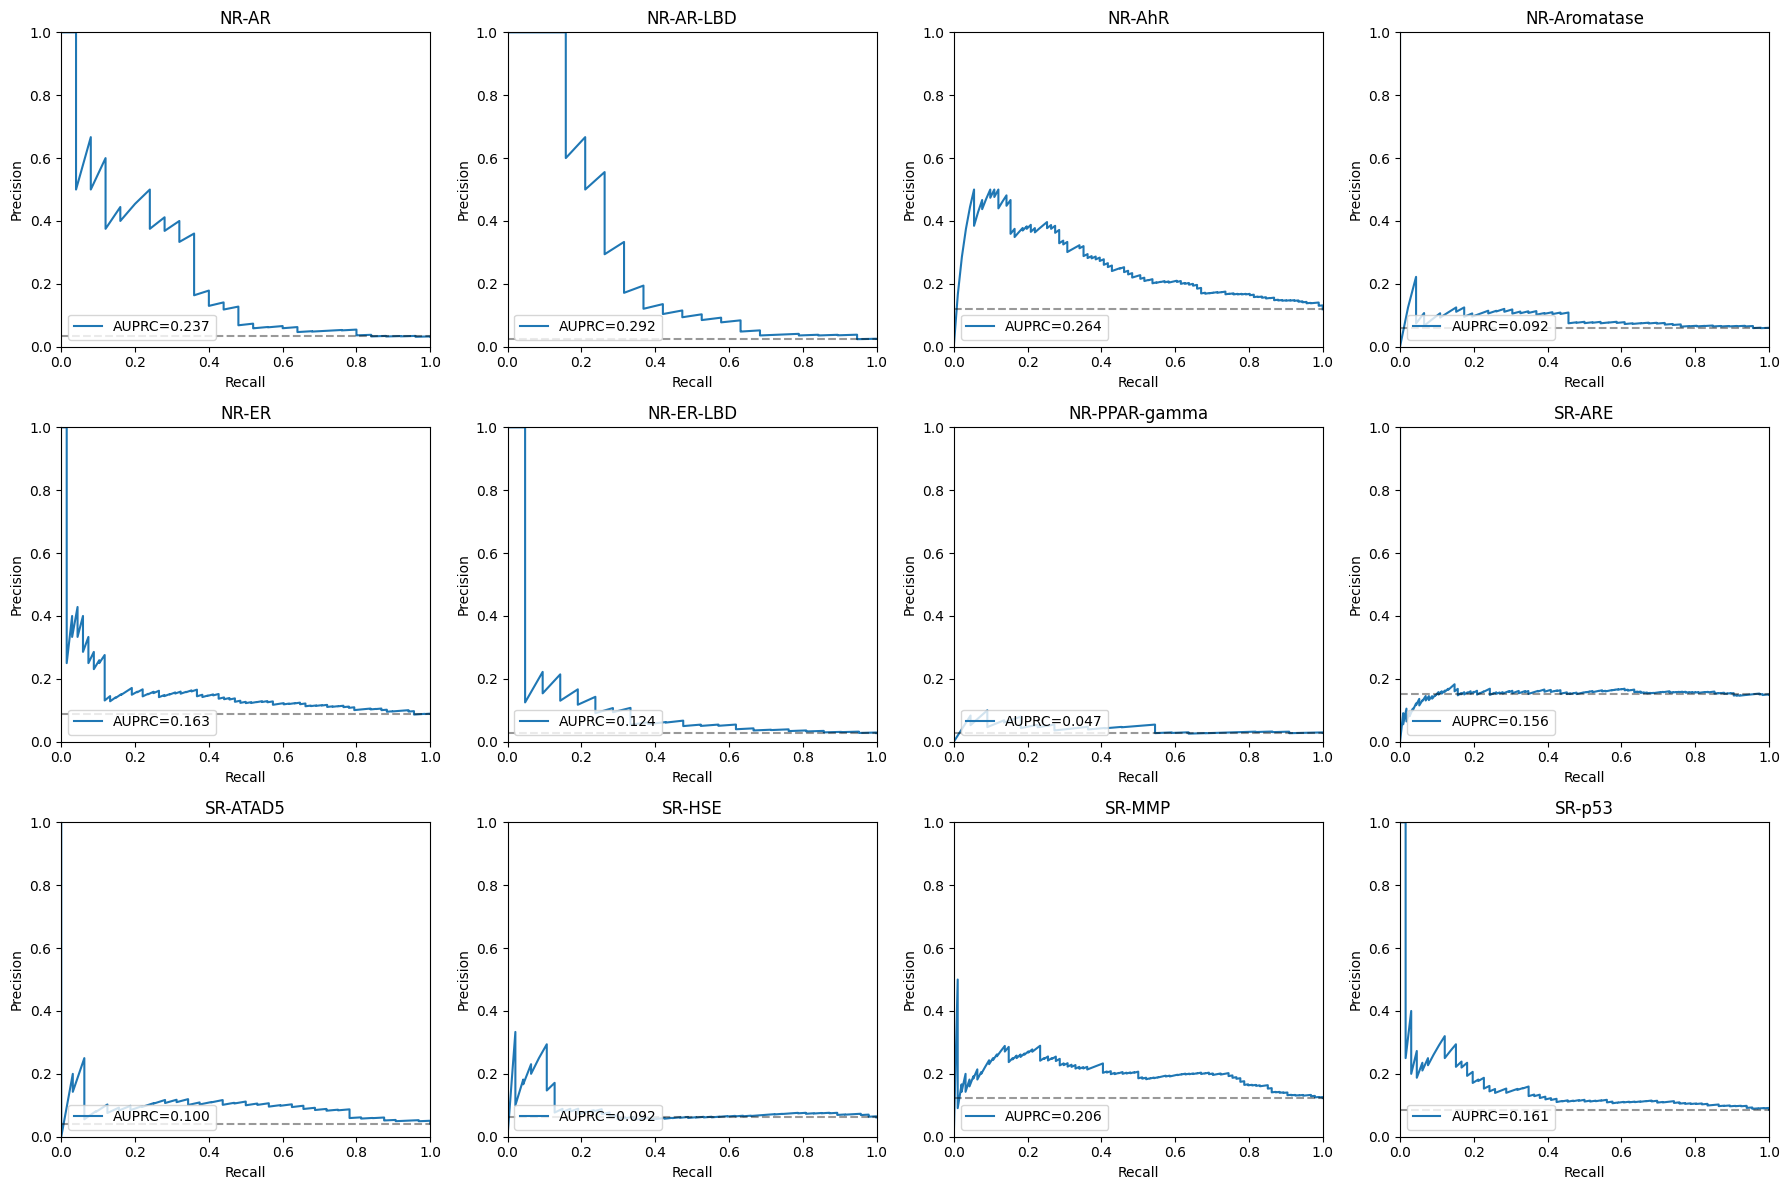

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for ax, task in zip(axes.ravel(), TASKS):
    if task in pr_curves:
        rec, prec, ap, base = pr_curves[task]
        ax.plot(rec, prec, label=f"AUPRC={ap:.3f}")
        ax.hlines(base, 0, 1, colors="k", linestyles="--", alpha=0.4)
        ax.set_title(task)
        ax.set_xlabel("Recall")
        ax.set_ylabel("Precision")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower left")
    else:
        ax.set_title(task)
        ax.text(0.5, 0.5, "insufficient class variation", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Tox21 test token accuracy using BEST pretrained checkpoint
TOX21_TEST_PATH = Path("data") / "Test" / "tox21_test_clean.csv"
best_ckpt_path = CHECKPOINT_DIR / f"{CHECKPOINT_STEM}_best.pt"

if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

# 1) Load tox21 test SMILES
tox21_test_df = pd.read_csv(TOX21_TEST_PATH)
tox21_test_smiles = tox21_test_df["canonical_smiles"].dropna().astype(str).tolist()
tox21_test_smiles = list(dict.fromkeys(tox21_test_smiles))

# 2) Convert + filter exactly like pretraining pipeline
tox21_test_selfies, tox21_failed = smiles_to_selfies(tox21_test_smiles)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)
tox21_test_x = encode_list(tox21_test_selfies)

# 3) Load best model weights
bundle = torch.load(best_ckpt_path, map_location=device)
model_best = PaperLikeSelfiesVAE(vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, latent_dim=LATENT_DIM).to(device)
model_best.load_state_dict(bundle["model_state_dict"])

# 4) Evaluate (same token-accuracy computation path as this notebook)
beta_eval = bundle["history"]["beta"][-1] if "history" in bundle and "beta" in bundle["history"] else 1.0
tox21_metrics = evaluate(model_best, tox21_test_x, beta=beta_eval)

print(f"Best checkpoint: {best_ckpt_path.name}")
print(f"Tox21 test SMILES: raw={len(tox21_test_smiles):,} | selfies_ok={len(tox21_test_selfies):,} | failed={tox21_failed:,}")
print(
    f"Tox21 test metrics -> "
    f"total={tox21_metrics['total']:.4f}, "
    f"recon_per_token={tox21_metrics['recon_per_token']:.4f}, "
    f"kl={tox21_metrics['kl']:.4f}, "
    f"token_acc={tox21_metrics['token_acc']:.4f}"
)

Best checkpoint: paper_like_selfies_chembl_zinc_seqconv_ce_best.pt
Tox21 test SMILES: raw=783 | selfies_ok=765 | failed=0
Tox21 test metrics -> total=68.5168, recon_per_token=0.9323, kl=29.2259, token_acc=0.7571


# Post-Trained VAE 

Fine-tuning the pretrained VAE on the Tox21 dataset.

## Necessary Imports and Modules

In [6]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import selfies as sf
from tqdm.auto import tqdm

SEED = 42
POST_EPOCHS = 20
BATCH_SIZE = 128
POST_LR = 1e-5
EVAL_EVERY = 1

# Toggle this to start/skip training when running all cells.
RUN_POST_TRAIN = True

DATA_ROOT = Path("data")
TOX21_TRAIN_PATH = DATA_ROOT / "Train" / "tox21_train_clean.csv"
TOX21_VAL_PATH = DATA_ROOT / "Val" / "tox21_val_clean.csv"
TOX21_TEST_PATH = DATA_ROOT / "Test" / "tox21_test_clean.csv"

PRETRAIN_CKPT = Path("artifacts") / "pretraining_checkpoints" / "paper_like_selfies_chembl_zinc_seqconv_ce_best.pt"
POSTTRAIN_SAVE_DIR = Path("artifacts") / "posttraining_checkpoints"
POSTTRAIN_SAVE_DIR.mkdir(parents=True, exist_ok=True)
POSTTRAIN_CKPT = POSTTRAIN_SAVE_DIR / "paper_like_selfies_chembl_zinc_posttrained_tox21.pt"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
)

## Loading the Pretrained Checkpoint

In [7]:
ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")
token_to_idx = ckpt["token_to_idx"]
idx_to_token = {i: tok for tok, i in token_to_idx.items()}

PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"
PAD_IDX = token_to_idx[PAD]
UNK_IDX = token_to_idx[UNK]
EOS_IDX = token_to_idx[EOS]

SEQ_LEN = int(ckpt["seq_len"])
VOCAB_SIZE = int(ckpt["vocab_size"])
MAX_LEN = int(ckpt["max_len"])
LATENT_DIM = int(ckpt["model_state_dict"]["linear_1.weight"].shape[0])

C:\Users\Taha\AppData\Local\Temp\ipykernel_13208\1436806741.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(PRETRAIN_CKPT, map_location="cpu")


## Tox21 Preprocessing

In [8]:
def load_smiles(path: Path) -> list[str]:
    df = pd.read_csv(path)
    smiles = df["canonical_smiles"].dropna().astype(str).tolist()
    return list(dict.fromkeys(smiles))

def smiles_to_selfies(smiles_list: list[str]) -> tuple[list[str], int]:
    out = []
    failed = 0
    for smi in smiles_list:
        try:
            out.append(sf.encoder(smi))
        except Exception:
            failed += 1
    return out, failed

def filter_selfies_len(selfies_list: list[str], max_len: int) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]

def filter_selfies_len(selfies_list: list[str], max_len: int) -> list[str]:
    return [s for s in selfies_list if len(list(sf.split_selfies(s))) <= max_len]


tox21_train_smiles = load_smiles(TOX21_TRAIN_PATH)
tox21_val_smiles = load_smiles(TOX21_VAL_PATH)
tox21_test_smiles = load_smiles(TOX21_TEST_PATH)

tox21_train_selfies, tr_failed = smiles_to_selfies(tox21_train_smiles)
tox21_val_selfies, va_failed = smiles_to_selfies(tox21_val_smiles)
tox21_test_selfies, te_failed = smiles_to_selfies(tox21_test_smiles)

tox21_train_selfies = filter_selfies_len(tox21_train_selfies, max_len=MAX_LEN)
tox21_val_selfies = filter_selfies_len(tox21_val_selfies, max_len=MAX_LEN)
tox21_test_selfies = filter_selfies_len(tox21_test_selfies, max_len=MAX_LEN)

print(f"SELFIES conversion failures train/val/test: {tr_failed} / {va_failed} / {te_failed}")
print(f"tox21 filtered sizes train/val/test: {len(tox21_train_selfies):,} / {len(tox21_val_selfies):,} / {len(tox21_test_selfies):,}")

def load_labels(path: Path) -> list[str]:
    df = pd.read_csv(path)
    tox21_tasks = ['NR-AR', 'NR-AR-LBD', 'NR-AhR',
    'NR-Aromatase', 'NR-ER','NR-ER-LBD', 
    'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
    'SR-HSE', 'SR-MMP', 'SR-p53']
    for tasks in tox21_tasks:
        if tasks not in df.columns:
            raise ValueError(f"{path} does not contain {tasks} column")
    labels_array = df[tox21_tasks].values.astype(float)
    return labels_array.tolist()

tox21_train_labels = load_labels(TOX21_TRAIN_PATH)
tox21_val_labels = load_labels(TOX21_VAL_PATH)
tox21_test_labels = load_labels(TOX21_TEST_PATH)

train_y = np.array(tox21_train_labels, dtype=np.float32)
val_y = np.array(tox21_val_labels, dtype=np.float32)
test_y = np.array(tox21_test_labels, dtype=np.float32)

# Calculate weight: Negatives / Positives
num_positives = train_y.sum(axis=0)
num_negatives = train_y.shape[0] - num_positives
pos_weights_np = num_negatives / (num_positives + 1e-5)
pos_weights = torch.tensor(pos_weights_np, dtype=torch.float32).to(device)

SELFIES conversion failures train/val/test: 0 / 0 / 0
tox21 filtered sizes train/val/test: 6,237 / 770 / 765


## Selfies Encoding

This preserves compatibility with pretrained weights. Any unseen token is mapped to UNK.

In [9]:
def tokenize_selfies(s: str) -> list[str]:
    return list(sf.split_selfies(s))


def encode_selfies(s: str) -> list[int]:
    ids = [token_to_idx.get(tok, UNK_IDX) for tok in tokenize_selfies(s)]
    ids = ids[:MAX_LEN]
    ids.append(EOS_IDX)
    return ids


def encode_list(selfies_list: list[str]) -> np.ndarray:
    out = np.full((len(selfies_list), SEQ_LEN), PAD_IDX, dtype=np.int64)
    for i, s in enumerate(selfies_list):
        ids = encode_selfies(s)
        out[i, :len(ids)] = ids
    return out


def unk_rate(selfies_list: list[str]) -> float:
    total = 0
    unk = 0
    for s in selfies_list:
        for tok in tokenize_selfies(s)[:MAX_LEN]:
            total += 1
            if tok not in token_to_idx:
                unk += 1
    return 0.0 if total == 0 else unk / total

train_x = encode_list(tox21_train_selfies)
val_x = encode_list(tox21_val_selfies)
test_x = encode_list(tox21_test_selfies)

print("encoded shapes:", train_x.shape, val_x.shape, test_x.shape)

encoded shapes: (6237, 121) (770, 121) (765, 121)


## Post-training Model Architecture 

In [10]:
class JointTokenDataset(Dataset):
    def __init__(self, x: np.ndarray, y: np.ndarray):
        self.x = torch.from_numpy(x).long()
        self.y = torch.from_numpy(y).float() 

    def __len__(self):
        return self.x.size(0)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

def build_property_predictor(latent_dim: int, 
                             hidden_dim: int, 
                             num_pred_layers: int, 
                             dropout_rate: float,
                             use_batchnorm: bool = True):
    layers = []
    if num_pred_layers == 0:
        return nn.Sequential(
            nn.Linear(latent_dim, 12)
        )
    
    else:
        layers.append(nn.Linear(latent_dim, hidden_dim))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        for i in range(1, num_pred_layers):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
        layers.append(nn.Linear(hidden_dim, 12))

    return nn.Sequential(*layers)

def ids_to_onehot(x_ids: torch.Tensor, vocab_size: int):
    return F.one_hot(x_ids, num_classes=vocab_size).float().transpose(1, 2).contiguous()

def kl_beta(epoch: int, anneal_epochs: int) -> float:
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))


In [14]:
class JointSelfiesVAEPredictor(nn.Module):
    def __init__(self, vocab_size: int, seq_len: int, latent_dim: int = 292,
                prop_hidden_dim: int = 1000, num_pred_layers: int = 2, prop_dropout: float = 0.2, use_batchnorm: bool = True
                ):
        super().__init__()
        self.vocab_size = vocab_size
        self.seq_len = seq_len

        # Conv1d expects [batch, channels, length], so we encode one-hot SELFIES as [B, vocab, seq].
        self.conv_1 = nn.Conv1d(in_channels=vocab_size, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, vocab_size, seq_len)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.flatten(1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(501, vocab_size)

        self.prediction_head = build_property_predictor(
            latent_dim=latent_dim,
            hidden_dim=prop_hidden_dim,
            num_pred_layers=num_pred_layers,
            dropout_rate=prop_dropout,
            use_batchnorm=use_batchnorm
        )

    def encoder(self, x_onehot: torch.Tensor):
        x = self.relu(self.conv_1(x_onehot))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.flatten(1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean: torch.Tensor, logvar: torch.Tensor):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z: torch.Tensor):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        logits = self.linear_4(out)
        return logits

    def forward(self, x_onehot: torch.Tensor):
        mean, logvar = self.encoder(x_onehot)
        z = self.sampling(mean, logvar)
        logits = self.decode(z)
        preds = self.prediction_head(mean)
        return logits, mean, logvar, preds
    
model_updated = JointSelfiesVAEPredictor(
    vocab_size=VOCAB_SIZE, 
    seq_len=SEQ_LEN, 
    latent_dim=LATENT_DIM
).to(device)
model_updated.load_state_dict(ckpt["model_state_dict"], strict=False)

_IncompatibleKeys(missing_keys=['prediction_head.0.weight', 'prediction_head.0.bias', 'prediction_head.3.weight', 'prediction_head.3.bias', 'prediction_head.6.weight', 'prediction_head.6.bias', 'prediction_head.6.running_mean', 'prediction_head.6.running_var', 'prediction_head.7.weight', 'prediction_head.7.bias'], unexpected_keys=[])

## Training Helpers & Loss Function

### Optional: Resume From A Previously Post-Trained Checkpoint

Use this if a post-training run was interrupted and you want to continue from that exact point. Leave RESUME_POSTTRAIN = False to start from pretrained chembl_zinc weights.

In [15]:
RESUME_POSTTRAIN = False
RESUME_CKPT_PATH = POSTTRAIN_CKPT

if RESUME_POSTTRAIN:
    if not RESUME_CKPT_PATH.exists():
        raise FileNotFoundError(f"Resume checkpoint not found: {RESUME_CKPT_PATH}")

    resume_ckpt = torch.load(RESUME_CKPT_PATH, map_location="cpu")
    model_updated.load_state_dict(resume_ckpt["model_state_dict"], strict=True)

    if "optimizer_state_dict" in resume_ckpt:
        optim_updated.load_state_dict(resume_ckpt["optimizer_state_dict"])

    prev_hist = resume_ckpt.get("post_history", {})
    done_epochs = len(prev_hist.get("train_total", []))
    print(f"Resumed model/optimizer from {RESUME_CKPT_PATH}")
    print(f"Previously completed post-training epochs: {done_epochs}")
else:
    print("RESUME_POSTTRAIN is False. Starting from pretrained chembl_zinc weights.")

optim_updated = torch.optim.Adam(model_updated.parameters(), lr=POST_LR, weight_decay=1e-3)
print("Loaded pretrained chembl_zinc weights and initialized prediction head.")

RESUME_POSTTRAIN is False. Starting from pretrained chembl_zinc weights.
Loaded pretrained chembl_zinc weights and initialized prediction head.


Post-Training Helpers

In [16]:
def updated_vae_loss(
    recon_logits, x_ids,
    mean, logvar,
    pred_logits, labels,
    pad_idx, pos_weights,
    prop_pred_loss_weight=0.7,
    kl_weight=0.1
):
    recon_loss = F.cross_entropy(
        recon_logits.reshape(-1, VOCAB_SIZE),
        x_ids.reshape(-1),
        ignore_index=pad_idx,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mean.pow(2) - logvar.exp()
    )

    pred_loss = F.binary_cross_entropy_with_logits(
        pred_logits,
        labels,
        reduction="mean",
        pos_weight=pos_weights
    )

    return (
        (1 - prop_pred_loss_weight) * (recon_loss + kl_weight * kl_loss)
        + prop_pred_loss_weight * pred_loss,
        recon_loss,
        kl_loss,
        pred_loss,
        x_ids.numel() - (x_ids == pad_idx).sum().item()
    )

In [31]:
def make_loader_joint(x: np.ndarray, y: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(JointTokenDataset(x, y), batch_size=batch_size, shuffle=shuffle)

def evaluate_joint(model: nn.Module, x: np.ndarray, y: np.ndarray, pos_weights:torch.Tensor, batch_size: int, prop_pred_loss_weight: float, beta: float = 1.0):
    loader = make_loader_joint(x, y, batch_size=batch_size, shuffle=False)
    
    model.eval()
    total_sum, recon_sum, kl_sum, pred_sum = 0.0, 0.0, 0.0, 0.0
    n_total = 0
    
    with torch.no_grad():
        for x_ids, labels in tqdm(loader, desc="eval", leave=False):
            x_ids = x_ids.to(device)
            labels = labels.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
            recon_logits, mean, logvar, pred_logits = model(x_onehot)

            # Use kl_weight=beta for annealing
            total, recon, kl, pred_loss, n_nonpad = updated_vae_loss(
                recon_logits, x_ids, mean, logvar, pred_logits, labels,
                pad_idx=PAD_IDX, pos_weights=pos_weights,
                prop_pred_loss_weight=prop_pred_loss_weight,
                kl_weight=beta
            )

            b = x_ids.size(0)
            total_sum += total.item() * b
            recon_sum += recon.item() * b
            kl_sum += kl.item() * b
            pred_sum += pred_loss.item() * b
            n_total += b

    return {
        "total": total_sum / max(n_total, 1),
        "recon": recon_sum / max(n_total, 1),
        "kl": kl_sum / max(n_total, 1),
        "pred": pred_sum / max(n_total, 1)
    }


def post_train_joint(
    model, optim, train_x, train_y,
    val_x, val_y,
    pos_weights,
    epochs, batch_size,
    prop_pred_loss_weight=0.7,
    kl_anneal_epochs=1
):
    train_loader = make_loader_joint(train_x, train_y, batch_size, shuffle=True)
    history = {"train_total": [], "train_recon": [], "train_pred": [],
               "val_total": [], "val_recon": [], "val_pred": []}

    for ep in tqdm(range(1, epochs+1), desc="post-train epochs"):
        beta = kl_beta(ep, kl_anneal_epochs)
        model.train()
        total_sum, recon_sum, kl_sum, pred_sum, n_total = 0.0, 0.0, 0.0, 0.0, 0

        for x_ids, labels in train_loader:
            x_ids = x_ids.to(device)
            labels = labels.to(device)
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
            optim.zero_grad()

            recon_logits, mean, logvar, pred_logits = model(x_onehot)

            total, recon, kl, pred_loss, n_nonpad = updated_vae_loss(
                recon_logits, x_ids, mean, logvar, pred_logits, labels,
                pad_idx=PAD_IDX, pos_weights=pos_weights,
                prop_pred_loss_weight=prop_pred_loss_weight,
                kl_weight=beta     # <- use beta for KL annealing
            )
            total.backward()
            optim.step()

            b = x_ids.size(0)
            total_sum += total.item() * b
            recon_sum += recon.item() * b
            kl_sum += kl.item() * b
            pred_sum += pred_loss.item() * b
            n_total += b

        history["train_total"].append(total_sum / n_total)
        history["train_recon"].append(recon_sum / n_total)
        history["train_pred"].append(pred_sum / n_total)

        # Evaluate
        val_metrics = evaluate_joint(model, val_x, val_y, pos_weights, batch_size, prop_pred_loss_weight, beta=beta)
        history["val_total"].append(val_metrics["total"])
        history["val_recon"].append(val_metrics["recon"])
        history["val_pred"].append(val_metrics["pred"])

        print(f"Epoch {ep} | Train total: {history['train_total'][-1]:.4f} | "
              f"Pred: {history['train_pred'][-1]:.4f} | Val total: {history['val_total'][-1]:.4f}")

    return model, history

optim_updated = torch.optim.Adam(model_updated.parameters(), lr=POST_LR, weight_decay=1e-3)
print("Loaded pretrained chembl_zinc weights and initialized prediction head.")

Loaded pretrained chembl_zinc weights and initialized prediction head.


Freezing Layers

In [32]:
for p in model_updated.gru.parameters():
    p.requires_grad = False
for p in model_updated.linear_4.parameters():
    p.requires_grad = False

## Execution

Set RUN_POST_TRAIN = True in the config cell, then run this cell.

if RUN_POST_TRAIN: print("Starting post-training from pretrained chembl_zinc checkpoint...") model, post_history = post_train( model=model, optim=optim, train_x=train_x, val_x=val_x, epochs=POST_EPOCHS, batch_size=BATCH_SIZE, eval_every=EVAL_EVERY, )

post_test_metrics = evaluate(model, test_x, batch_size=BATCH_SIZE)
print("Post-training test metrics:", post_test_metrics)


else: print("RUN_POST_TRAIN is False. Set RUN_POST_TRAIN=True in the config cell to begin training.") post_history = None post_test_metrics = None

In [33]:
if RUN_POST_TRAIN:
    print("Starting post-training from pretrained chembl_zinc checkpoint...")
    model, post_history = post_train_joint(
    model=model_updated,
    optim=optim_updated,
    train_x=train_x,
    train_y=train_y,
    val_x=val_x,
    val_y=val_y,
    epochs=POST_EPOCHS,
    batch_size=BATCH_SIZE,
    pos_weights=pos_weights,
    prop_pred_loss_weight = 0.7
)

    post_test_metrics = evaluate_joint(model, test_x, test_y, pos_weights = pos_weights, batch_size=BATCH_SIZE, prop_pred_loss_weight = 0.7)
    print("Post-training test metrics:", post_test_metrics)
else:
    print("RUN_POST_TRAIN is False. Set RUN_POST_TRAIN=True in the config cell to begin training.")
    post_history = None
    post_test_metrics = None

Starting post-training from pretrained chembl_zinc checkpoint...


post-train epochs:   5%|▌         | 1/20 [00:03<01:11,  3.78s/it]

Epoch 1 | Train total: 1.1976 | Pred: 1.2931 | Val total: 1.3811


post-train epochs:  10%|█         | 2/20 [00:07<01:05,  3.65s/it]

Epoch 2 | Train total: 1.1726 | Pred: 1.2629 | Val total: 1.3878


...

post-train epochs:  95%|█████████▌| 19/20 [01:10<00:03,  3.79s/it]

Epoch 19 | Train total: 1.0716 | Pred: 1.1485 | Val total: 1.4011


post-train epochs: 100%|██████████| 20/20 [01:14<00:00,  3.74s/it]


Epoch 20 | Train total: 1.0712 | Pred: 1.1477 | Val total: 1.4031


Post-training test metrics: {'total': 1.376905375524284, 'recon': 0.8724878616582334, 'kl': 0.062288583893012374, 'pred': 1.5663891750223495}


## Save Post-Trained Checkpoint

This saves everything needed to continue later without restarting from pretraining.

In [ ]:
SAVE_POSTTRAINED = True

if SAVE_POSTTRAINED:
    if post_history is None:
        raise RuntimeError("No post-training history found. Run post-training first.")

    torch.save(
        {
            "model_state_dict": model_updated.state_dict(),
            "optimizer_state_dict": optim_updated.state_dict(),
            "token_to_idx": token_to_idx,
            "seq_len": SEQ_LEN,
            "vocab_size": VOCAB_SIZE,
            "max_len": MAX_LEN,
            "latent_dim": LATENT_DIM,
            "post_history": post_history,
            "post_test_metrics": post_test_metrics,
            "source_pretrain_checkpoint": str(PRETRAIN_CKPT),
        },
        POSTTRAIN_CKPT,
    )
    print(f"Saved post-trained checkpoint: {POSTTRAIN_CKPT}")
else:
    print("SAVE_POSTTRAINED is False. Set SAVE_POSTTRAINED=True to write checkpoint.")

## Optional: Plot Post-Training Curves

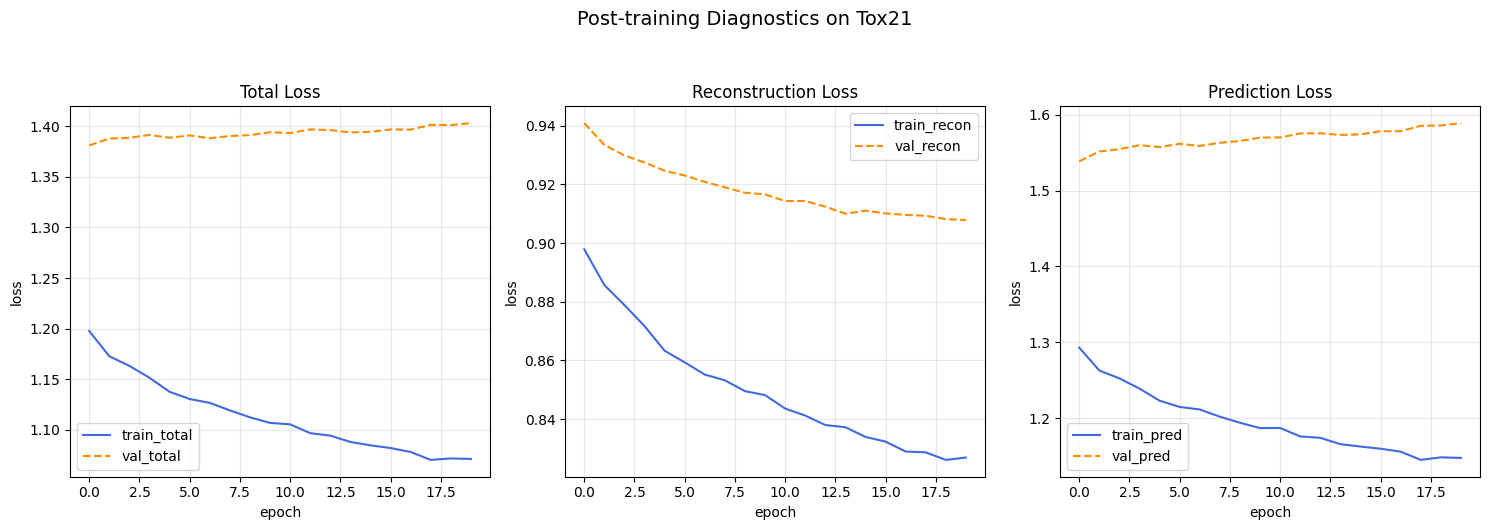

In [34]:
import matplotlib.pyplot as plt

if post_history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = [
        ("total", "Total Loss"),
        ("recon", "Reconstruction Loss"),
        ("pred", "Prediction Loss")
    ]
    
    for i, (key, title) in enumerate(metrics):
        axes[i].plot(post_history[f"train_{key}"], label=f"train_{key}", color='royalblue')
        axes[i].plot(post_history[f"val_{key}"], label=f"val_{key}", color='darkorange', linestyle='--')
        
        axes[i].set_xlabel("epoch")
        axes[i].set_ylabel("loss")
        axes[i].set_title(title)
        axes[i].grid(alpha=0.3)
        axes[i].legend()

    plt.suptitle("Post-training Diagnostics on Tox21", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("No post-training history to plot yet.")

## Evaluation of the Testing Set

In [43]:
from torchmetrics import MetricCollection
from torchmetrics.classification import (
    MultilabelAUROC,
    MultilabelAveragePrecision,
    MultilabelAccuracy,
    MultilabelF1Score,
    MultilabelPrecision,
    MultilabelRecall
)

def get_metrics_collection(num_labels: int):
    """
    Creates a MetricCollection for multi-label classification.
    average=None ensures we get individual scores for EACH label.
    """
    metrics = MetricCollection({
        "AUROC": MultilabelAUROC(num_labels=num_labels, average=None),
        "AUPRC": MultilabelAveragePrecision(num_labels=num_labels, average=None),
        "Accuracy": MultilabelAccuracy(num_labels=num_labels, average=None),
        "F1": MultilabelF1Score(num_labels=num_labels, average=None),
        "Precision": MultilabelPrecision(num_labels=num_labels, average=None),
        "Recall": MultilabelRecall(num_labels=num_labels, average=None)
    })
    return metrics.to(device)

def run_final_test(model: torch.nn.Module, test_x, test_y, batch_size: int):

    num_labels = 12
    metrics = get_metrics_collection(num_labels)
    test_loader = make_loader_joint(test_x, test_y, batch_size=batch_size, shuffle=False)
    
    model.eval()
    with torch.no_grad():
        for x_ids, labels in tqdm(test_loader, desc="Testing Model", leave=True):
            x_ids = x_ids.to(device)
            labels = labels.to(device).long()
            x_onehot = ids_to_onehot(x_ids, VOCAB_SIZE)
            recon_logits, mean, logvar, pred_logits = model(x_onehot)
            pred_probs = torch.sigmoid(pred_logits)
            metrics.update(pred_probs, labels)
    results = metrics.compute()

    print("FINAL TEST SET METRICS (PER LABEL):")
    
    for i in range(num_labels):
        print(f"--- Property Label {i} ---")
        print(f"  AUROC    : {results['AUROC'][i].item():.4f}")
        print(f"  AUPRC    : {results['AUPRC'][i].item():.4f}")
        print(f"  Accuracy : {results['Accuracy'][i].item():.4f}")
        print(f"  F1 Score : {results['F1'][i].item():.4f}")
        print(f"  Precision: {results['Precision'][i].item():.4f}")
        print(f"  Recall   : {results['Recall'][i].item():.4f}\n")
        
    metrics.reset()
    return results

final_test_results = run_final_test(
    model=model_updated, 
    test_x=test_x, 
    test_y=test_y, 
    batch_size=BATCH_SIZE
)

Testing Model: 100%|██████████| 6/6 [00:00<00:00, 10.55it/s]


FINAL TEST SET METRICS (PER LABEL):
--- Property Label 0 ---
  AUROC    : 0.4541
  AUPRC    : 0.0309
  Accuracy : 0.2902
  F1 Score : 0.0686
  Precision: 0.0360
  Recall   : 0.7407

--- Property Label 1 ---
  AUROC    : 0.4826
  AUPRC    : 0.0258
  Accuracy : 0.3542
  F1 Score : 0.0500
  Precision: 0.0259
  Recall   : 0.6842

--- Property Label 2 ---
  AUROC    : 0.5318
  AUPRC    : 0.1284
  Accuracy : 0.3399
  F1 Score : 0.2195
  Precision: 0.1275
  Recall   : 0.7889

--- Property Label 3 ---
  AUROC    : 0.4411
  AUPRC    : 0.0602
  Accuracy : 0.2379
  F1 Score : 0.0961
  Precision: 0.0518
  Recall   : 0.6596

--- Property Label 4 ---
  AUROC    : 0.4953
  AUPRC    : 0.0877
  Accuracy : 0.2980
  F1 Score : 0.1674
  Precision: 0.0939
  Recall   : 0.7714

--- Property Label 5 ---
  AUROC    : 0.5650
  AUPRC    : 0.0409
  Accuracy : 0.2288
  F1 Score : 0.0545
  Precision: 0.0282
  Recall   : 0.8095

--- Property Label 6 ---
  AUROC    : 0.5521
  AUPRC    : 0.0443
  Accuracy : 0.4719
  F